In [92]:
import json
import operator
import re
from pathlib import Path
from typing import TypedDict, Annotated

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END

llm      = ChatOllama(model="llama3.2:latest", temperature=0)
DATA_DIR = Path("./data")

print(f"✅ Setup")


✅ Setup


In [ ]:
# Schema di stato condiviso tra tutti i nodi
class StatoRichiesta(TypedDict, total=False):
    # Input
    richiesta:              str     # messaggio originale del cliente
    customer_id:            str     # ID del cliente
    claim_id:               str     # ID della pratica
    customer_policy_id:     str     # ID dell'assicurazione del cliente
    customer_loss_type:     str     # tipo di pratica dichiarata dall'utente (incidente, furto, allagamento)
    estimated_damage:       int     # valore stimato dell'indennizzo
    documents:              list    # lista dei documenti inviati dal cliente (come stringhe)

    # Risultati intermedi
    customer_name:          str     # prende il nome del cliente (probabilmente inutile, poi vediamo)
    risk_tier:              str     # possibile approfondimento futuro (sale con il numeri di incidenti)
    policy_id:              str     # prende l'assicurazione effettiva (bisogna verificare che sia effettivamente posseduta dal cliente)
    product:                str     # prodotto assicurato (casa / macchina)
    coverage:               str     # da cosa ti copre l'assicurazione (bisogna verificare anche questo)
    deductible:             int     # franchigia (parte che il cliente deve pagare comunque)
    max_claims:             int     # tetto massimo coperto (probabilmente oltre questa soglia il perito non può agisce)
    active:                 bool    # flag che indica se l'assicurazione è attivo o meno (fondamentale)

    # Approfondimento di loss_type
    loss_type:              str     # tipo di pratica
    required_documents:     list    # lista dei documenti richiesti dall'assicurazione (come stringhe)
    automatic_review_max:   int     # soglia massima per indennizzo automatico

    # INFO DI SISTEMA
    esito:                  str    # APPROVATO | ESCALATION | RIFIUTO | AMBIGUO | ERRORE
    motivazione:            str    # motivazione dell'esito
    risposta_finale:        str    # risposta finale data dall'agente
    retry_count:            int    # quanti cicli di chiarimento
    chiarimento:            str    # risposta del cliente in caso di ambiguità
    errori:                 list   # lista degli errori riscontrati (non so se tenerla)

print("Campi dello stato:", list(StatoRichiesta.__annotations__.keys()))

Campi dello stato: ['richiesta', 'customer_id', 'claim_id', 'customer_policy_id', 'customer_loss_type', 'estimated_damage', 'documents', 'customer_name', 'risk_tier', 'policy_id', 'product', 'coverage', 'deductible', 'max_claims', 'active', 'loss_type', 'required_documents', 'automatic_review_max', 'esito', 'motivazione', 'risposta_finale', 'retry_count', 'chiarimento', 'errori']


In [94]:
class Agent:
    """Agente ReAct"""

    def __init__(self, model, tools, system=""):
        self.system = system

        class AgentState(TypedDict):
            messages: Annotated[list[AnyMessage], operator.add]

        graph = StateGraph(AgentState)
        graph.add_node("llm",    self.call_llm)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()

        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state):
        """Controlla se il LLM ha richiesto almeno un tool call."""
        return len(state["messages"][-1].tool_calls) > 0

    def call_llm(self, state):
        """Nodo llm: invoca il modello con i messaggi correnti."""
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {"messages": [message]}

    def take_action(self, state):
        """Nodo action: esegue i tool richiesti e raccoglie i risultati."""
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"    🔧 {t['name']}({t['args']})")
            if t["name"] not in self.tools:
                result = f"Tool '{t['name']}' non esiste. Disponibili: {list(self.tools.keys())}"
            else:
                result = self.tools[t["name"]].invoke(t["args"])
            results.append(ToolMessage(
                tool_call_id=t["id"], name=t["name"], content=str(result)
            ))
        return {"messages": results}

print("✅ Classe Agent definita")

✅ Classe Agent definita


In [95]:
tools_orchestratore = []
agente_orchestratore = Agent(model=llm, tools=tools_orchestratore, system=f"""
Inserire system prompt qui
""")


tools_estrapolatore = []
agente_estrapolatore = Agent(model=llm, tools=tools_estrapolatore, system=f"""
Sei un agente specializzato nell'estrazione di informazioni da richieste di sinistri assicurativi.
Il tuo unico compito è analizzare la richiesta del cliente ed estrarre i seguenti dati in formato JSON:
- customer_id (es. 'AS001')
- claim_id (es. 'CL001')
- customer_policy_id (es. 'POL001')
- customer_loss_type (es. 'collision', 'water_damage', 'theft')
- estimated_damage (valore numerico intero)
- documents (lista di stringhe dei documenti citati, es. ['photo', 'police report'])

Rispondi ESCLUSIVAMENTE con un oggetto JSON valido contenente queste chiavi.
""")


tools_policy = []
agente_policy = Agent(model=llm, tools=tools_policy, system=f"""
Inserire system prompt qui
""")


tools_esito = []
agente_esito = Agent(model=llm, tools=tools_esito, system=f"""
Inserire system prompt qui
""")

In [ ]:
@tool
def estrapola_dati(richiesta: str) -> str:
    """
    Tool che invoca l'Agente Estrapolatore per analizzare il testo di una richiesta
    ed estrarre customer_id, claim_id, customer_policy_id, customer_loss_type, 
    estimated_damage e documents in formato JSON.
    """
    # Invocazione del sotto-agente
    input_state = {
        "messages": [("user", f"Estrai i dati da questa richiesta: '{richiesta}'")]
    }
    
    result_state = agente_estrapolatore.graph.invoke(input_state)
    
    # Otteniamo la risposta finale del sotto-agente
    last_message = result_state["messages"][-1].content
    
    return last_message

In [97]:
def analizza_documenti():
    pass

In [98]:
def verifica_copertura():
    pass

In [99]:
def rifiuta_claim():
    pass

In [100]:
def accetta_claim():
    pass

In [101]:
def chiedi_chiarimenti():
    pass

In [102]:
def chiama_perito():
    pass

In [103]:
def formula_esito():
    pass

In [104]:
def verifica_copertura_e_tipo_polizza():
    pass

In [105]:
def calcola_budget_e_limiti():
    pass

In [ ]:
builder = StateGraph(StatoRichiesta)

# Aggiungi nodi
builder.add_node("estrapola_dati",      estrapola_dati)
builder.add_node("analizza_documenti",  analizza_documenti)
builder.add_node("verifica_copertura",  verifica_copertura)
builder.add_node("rifiuta_claim",       rifiuta_claim)
builder.add_node("accetta_claim",       accetta_claim)
builder.add_node("chiedi_chiarimenti",  chiedi_chiarimenti)
builder.add_node("chiama_perito",       chiama_perito)
builder.add_node("formula_esito",       formula_esito)

# Archi fissi
builder.add_edge(START,                 "estrapola_dati")
builder.add_edge("estrapola_dati",      "analizza_documenti")
builder.add_edge("chiedi_chiarimenti",  "analizza_documenti")
builder.add_edge("rifiuta_claim",       "formula_esito")
builder.add_edge("accetta_claim",       "formula_esito")
builder.add_edge("formula_esito",       END)

# Archi condizionali

#Ciclo
builder.add_conditional_edges(
    "analizza_documenti",
    analizza_documenti,
    {
        "tutti i documenti richiesti sono presenti": "verifica_copertura",
        "alcuni documenti mancanti": "chiedi_chiarimenti"
    }
)

# If
builder.add_conditional_edges(
    "verifica_copertura",
    verifica_copertura_e_tipo_polizza,
    {
        "non coperto / oltre tetto massimo": "rifiuta_claim",
        "nel budget di accettazione automatica": "accetta_claim",
        "verifica con il perito": "chiama_perito"
    }
)

# If
builder.add_conditional_edges(
    "chiama_perito",
    calcola_budget_e_limiti,
    {
        "rifiutato dal perito": "rifiuta_claim",
        "approvato dal perito": "accetta_claim"
    }
)

# Compila il grafo
graph = builder.compile()
print("✅ Grafo compilato — nodi:", list(builder.nodes.keys()))

✅ Grafo compilato — nodi: ['estrapola_dati', 'analizza_documenti', 'verifica_copertura', 'rifiuta_claim', 'accetta_claim', 'chiedi_chiarimenti', 'chiama_perito', 'formula_esito']


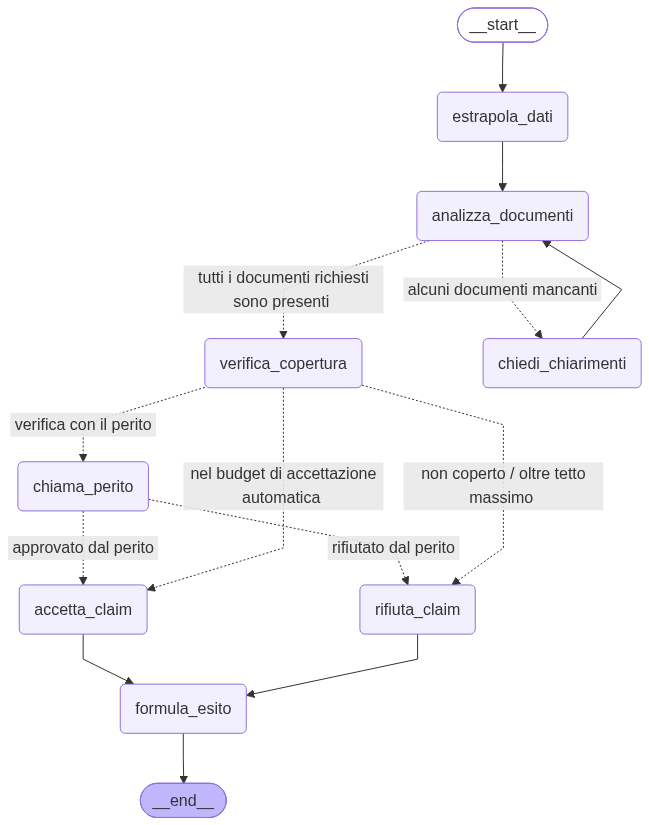

In [107]:
# Visualizza il grafo (richiede graphviz o pillow)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())